# Notebook 2: Implementacja modeli

## Analiza sentymentu polskich recenzji produktów

W tym notebooku implementujemy dwa podejścia do klasyfikacji sentymentu:

1. **Podejście klasyczne:** TF-IDF + SVM / Naive Bayes
2. **Podejście Transformer:** Fine-tuning modelu HerBERT (polski BERT)

Dane pochodzą z Notebooka 1.

## 1. Instalacja bibliotek i import

In [2]:
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)


## 2. Wczytanie danych

In [4]:
# Wczytanie danych zapisanych przez notebook 1
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Definicja zmiennych ze strukturą danych (zgodnie z notebookiem 1)
# Definicja kolumn zgodnie z zapisaną strukturą z Notebooka 1 i użyciem w kolejnych komórkach
LABEL_COL = "sentiment"        # Nowa nazwa klasy docelowej (0 lub 1)
CLEAN_COL = "text_clean"       # Kolumna dla TF-IDF (tekst po lematyzacji)
TEXT_TRANSFORMER = "text"      # Kolumna dla HerBERTa (surowy tekst)

Train: 7000, Val: 1500, Test: 1500


---
## CZĘŚĆ A: Podejście klasyczne (TF-IDF + klasyfikatory)

Implementujemy pipeline: TF-IDF → klasyfikator (SVM, Naive Bayes, Logistic Regression)

In [5]:
# Przygotowanie danych dla podejścia klasycznego
X_train_clean = train_df[CLEAN_COL].fillna("").values
X_val_clean = val_df[CLEAN_COL].fillna("").values
X_test_clean = test_df[CLEAN_COL].fillna("").values

y_train = train_df[LABEL_COL].values
y_val = val_df[LABEL_COL].values
y_test = test_df[LABEL_COL].values

In [8]:
# Wektoryzacja TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),  # unigramy i bigramy
    min_df=2,
    max_df=0.95,
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf = tfidf.transform(X_val_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print(f"Wymiary macierzy TF-IDF (train): {X_train_tfidf.shape}")
print(f"Liczba cech (unikalne n-gramy): {X_train_tfidf.shape[1]}")

Wymiary macierzy TF-IDF (train): (7000, 10000)
Liczba cech (unikalne n-gramy): 10000


In [9]:
# Trening klasyfikatorów klasycznych
classifiers = {
    "SVM (LinearSVC)": LinearSVC(max_iter=5000, random_state=42),
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
}

classic_results = {}

for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Trening: {name}")
    print(f"{'='*50}")

    # Trening
    clf.fit(X_train_tfidf, y_train)

    # Predykcja na zbiorze walidacyjnym
    y_val_pred = clf.predict(X_val_tfidf)

    # Metryki
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="weighted")

    classic_results[name] = {
        "model": clf,
        "val_accuracy": acc,
        "val_f1": f1,
        "val_predictions": y_val_pred,
    }

    print(f"Accuracy (val): {acc:.4f}")
    print(f"F1-score (val): {f1:.4f}")
    print(f"\nRaport klasyfikacji (val):")
    print(
        classification_report(
            y_val, y_val_pred, target_names=["Neutralny", "Mowa nienawiści"]
        )
    )


Trening: SVM (LinearSVC)
Accuracy (val): 0.6973
F1-score (val): 0.6834

Raport klasyfikacji (val):
                 precision    recall  f1-score   support

      Neutralny       0.75      0.84      0.79      1037
Mowa nienawiści       0.51      0.38      0.44       463

       accuracy                           0.70      1500
      macro avg       0.63      0.61      0.62      1500
   weighted avg       0.68      0.70      0.68      1500


Trening: Naive Bayes
Accuracy (val): 0.7047
F1-score (val): 0.6657

Raport klasyfikacji (val):
                 precision    recall  f1-score   support

      Neutralny       0.73      0.91      0.81      1037
Mowa nienawiści       0.55      0.25      0.34       463

       accuracy                           0.70      1500
      macro avg       0.64      0.58      0.58      1500
   weighted avg       0.67      0.70      0.67      1500


Trening: Logistic Regression
Accuracy (val): 0.7140
F1-score (val): 0.6424

Raport klasyfikacji (val):
          

Najlepszy klasyfikator klasyczny: SVM (LinearSVC)
F1-score (val): 0.6834

Wyniki na zbiorze testowym (SVM (LinearSVC)):
Accuracy: 0.6847
F1-score: 0.6649

Raport klasyfikacji (test):
                 precision    recall  f1-score   support

      Neutralny       0.74      0.84      0.79      1038
Mowa nienawiści       0.48      0.33      0.39       462

       accuracy                           0.68      1500
      macro avg       0.61      0.59      0.59      1500
   weighted avg       0.66      0.68      0.66      1500



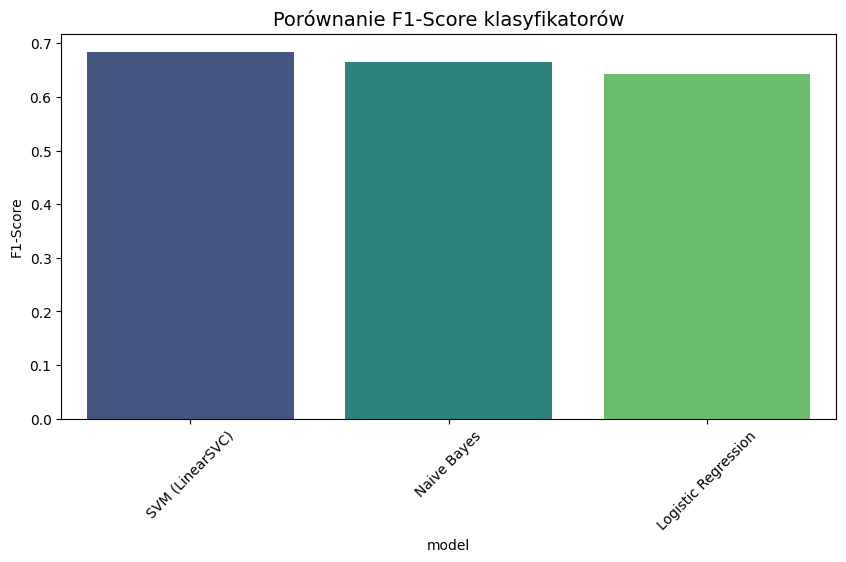

In [14]:
# Wybór najlepszego klasyfikatora klasycznego
best_classic_name = max(classic_results, key=lambda x: classic_results[x]["val_f1"])
best_classic = classic_results[best_classic_name]

print(f"Najlepszy klasyfikator klasyczny: {best_classic_name}")
print(f"F1-score (val): {best_classic['val_f1']:.4f}")

# Ewaluacja na zbiorze testowym
y_test_pred_classic = best_classic["model"].predict(X_test_tfidf)
classic_test_acc = accuracy_score(y_test, y_test_pred_classic)
classic_test_f1 = f1_score(y_test, y_test_pred_classic, average="weighted")

print(f"\nWyniki na zbiorze testowym ({best_classic_name}):")
print(f"Accuracy: {classic_test_acc:.4f}")
print(f"F1-score: {classic_test_f1:.4f}")
print(f"\nRaport klasyfikacji (test):")
print(
    classification_report(
        y_test, y_test_pred_classic, target_names=["Neutralny", "Mowa nienawiści"]
    )
)
results_data = pd.DataFrame.from_dict(classic_results, orient='index')
results_data['model'] = results_data.index

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=results_data, x='model', y='val_f1', palette='viridis', ax=ax)
ax.set_title('Porównanie F1-Score klasyfikatorów', fontsize=14)
ax.set_ylabel('F1-Score')
plt.xticks(rotation=45)
plt.show()

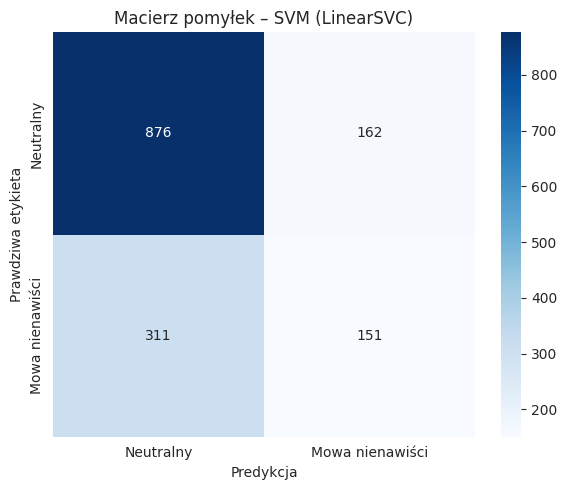

In [20]:
# Macierz pomyłek - podejście klasyczne
cm_classic = confusion_matrix(y_test, y_test_pred_classic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_classic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Neutralny", "Mowa nienawiści"],
    yticklabels=["Neutralny", "Mowa nienawiści"],
)
plt.title(f"Macierz pomyłek – {best_classic_name}")
plt.xlabel("Predykcja")
plt.ylabel("Prawdziwa etykieta")
plt.tight_layout()
plt.show()


---
## CZĘŚĆ B: Podejście oparte na Transformerach (HerBERT)

Fine-tuning modelu [HerBERT](https://huggingface.co/allegro/herbert-base-cased) – do wykrywania mowy nienawiści w języku polskim”.

**Uwaga:** Uruchom ten fragment na GPU w Google Colab (Runtime → Change runtime type → GPU).

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup

# Sprawdzenie GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Urządzenie: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Urządzenie: cuda
GPU: Tesla T4


In [13]:
# Załadowanie tokenizatora i modelu HerBERT
MODEL_NAME = "allegro/herbert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

print(f"Model: {MODEL_NAME}")
print(f"Parametry: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.sso.sso_relationship.bias              | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.sso.sso_relationship.weight            | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly in

Model: allegro/herbert-base-cased
Parametry: 124,444,418


In [24]:
class SentimentDataset(Dataset):
    """Dataset dla recenzji z sentymentem."""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(label, dtype=torch.long),
        }

In [25]:
# Przygotowanie DataLoaderów (używamy surowego tekstu, nie przetworzonego)
MAX_LENGTH = 128
BATCH_SIZE = 16

train_dataset = SentimentDataset(
    train_df[TEXT_TRANSFORMER].values, train_df[LABEL_COL].values, tokenizer, MAX_LENGTH
)
val_dataset = SentimentDataset(
    val_df[TEXT_TRANSFORMER].values, val_df[LABEL_COL].values, tokenizer, MAX_LENGTH
)
test_dataset = SentimentDataset(
    test_df[TEXT_TRANSFORMER].values, test_df[LABEL_COL].values, tokenizer, MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Batche treningowe: {len(train_loader)}")
print(f"Batche walidacyjne: {len(val_loader)}")

Batche treningowe: 438
Batche walidacyjne: 94


In [26]:
# Hiperparametry treningu
EPOCHS = 3
LEARNING_RATE = 2e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)

In [27]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """Jedna epoka treningu."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    """Ewaluacja modelu."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids, attention_mask=attention_mask, labels=labels
            )

            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, accuracy, f1, np.array(all_preds), np.array(all_labels)

In [28]:
# Pętla treningowa
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print(f"Rozpoczynam trening HerBERT ({EPOCHS} epok)...\n")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(
        f"Epoka {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )

Rozpoczynam trening HerBERT (3 epok)...

Epoka 1/3 | Train Loss: 0.5887 | Train Acc: 0.6921 | Val Loss: 0.5336 | Val Acc: 0.7540 | Val F1: 0.7301
Epoka 2/3 | Train Loss: 0.4852 | Train Acc: 0.7644 | Val Loss: 0.5385 | Val Acc: 0.7553 | Val F1: 0.7302
Epoka 3/3 | Train Loss: 0.3816 | Train Acc: 0.8293 | Val Loss: 0.5842 | Val Acc: 0.7480 | Val F1: 0.7371


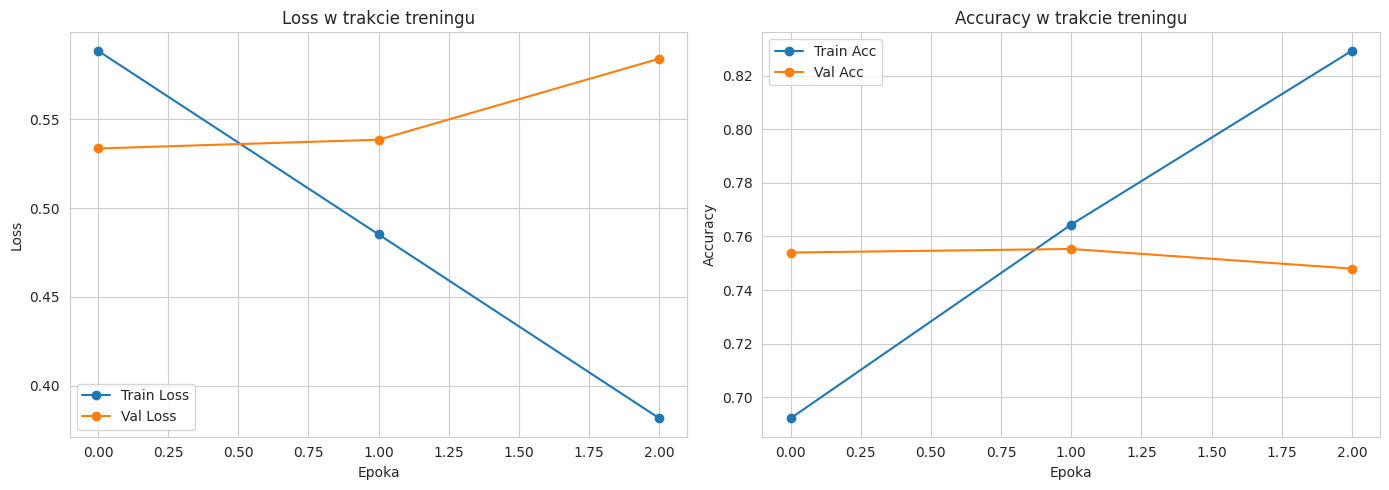

In [31]:
# Wykresy treningu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["val_loss"], label="Val Loss", marker="o")
axes[0].set_title("Loss w trakcie treningu")
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(history["val_acc"], label="Val Acc", marker="o")
axes[1].set_title("Accuracy w trakcie treningu")
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [32]:
# Ewaluacja HerBERT na zbiorze testowym
test_loss, test_acc, test_f1, y_test_pred_transformer, y_test_true = evaluate(
    model, test_loader, device
)

print(f"Wyniki HerBERT na zbiorze testowym:")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"\nRaport klasyfikacji:")
print(
    classification_report(
        y_test_true, y_test_pred_transformer,
        target_names=["Neutralny", "Mowa Nienawiści"]
    )
)

Wyniki HerBERT na zbiorze testowym:
Accuracy: 0.7247
F1-score: 0.7166

Raport klasyfikacji:
                 precision    recall  f1-score   support

      Neutralny       0.78      0.84      0.81      1038
Mowa Nienawiści       0.56      0.47      0.51       462

       accuracy                           0.72      1500
      macro avg       0.67      0.65      0.66      1500
   weighted avg       0.71      0.72      0.72      1500



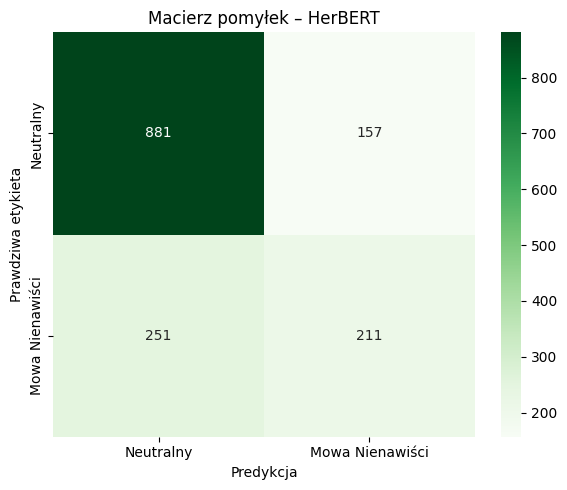

In [ ]:
# Macierz pomyłek - Transformer
cm_transformer = confusion_matrix(y_test_true, y_test_pred_transformer)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_transformer,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Neutralny", "Mowa Nienawiści"],
    yticklabels=["Neutralny", "Mowa Nienawiści"],
)
plt.title("Macierz pomyłek – HerBERT")
plt.xlabel("Predykcja")
plt.ylabel("Prawdziwa etykieta")
plt.tight_layout()
plt.show()

In [ ]:
# Zapis predykcji do pliku (do analizy w Notebooku 3)
results_df = test_df.copy()
results_df["pred_classic"] = y_test_pred_classic
results_df["pred_transformer"] = y_test_pred_transformer
results_df.to_csv("test_predictions.csv", index=False)

# Zapis podsumowania wyników
summary = {
    "classic_name": best_classic_name,
    "classic_accuracy": classic_test_acc,
    "classic_f1": classic_test_f1,
    "transformer_name": "HerBERT",
    "transformer_accuracy": test_acc,
    "transformer_f1": test_f1,
}

with open("results_summary.pkl", "wb") as f:
    pickle.dump(summary, f)

print("Predykcje zapisane do: test_predictions.csv")
print("Podsumowanie wyników zapisane do: results_summary.pkl")

Predykcje zapisane do: test_predictions.csv
Podsumowanie wyników zapisane do: results_summary.pkl


## Podsumowanie

W tym notebooku:
- Zaimplementowaliśmy podejście klasyczne: TF-IDF + SVM/Naive Bayes/Logistic Regression
- Zaimplementowaliśmy fine-tuning modelu HerBERT (Transformer)
- Wyniki obu podejść zapisano do plików do dalszej analizy

Szczegółowe porównanie i analiza błędów znajdują się w Notebooku 3.